# Practice

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures

In [5]:
df = pd.read_csv('SalaryGrowth.csv')
df.head()

,Years of Experience,Number of Projects,Salary
0,1,1,25000
1,2,2,30000
2,3,2,35000
3,4,3,45000
4,5,3,50000


In [9]:
df.columns


Index(['Years of Experience', 'Number of Projects', 'Salary'], dtype='object')

In [14]:
df.dtypes

Years of Experience    int64
Number of Projects     int64
Salary                 int64
dtype: object

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Years of Experience  10 non-null     int64
 1   Number of Projects   10 non-null     int64
 2   Salary               10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [12]:
df.isna().sum()

Years of Experience    0
Number of Projects     0
Salary                 0
dtype: int64

In [15]:
y = df[['Salary']]
x = df.drop('Salary',axis=1)

In [18]:
y.head()

,Salary
0,25000
1,30000
2,35000
3,45000
4,50000


In [19]:
x.head()

,Years of Experience,Number of Projects
0,1,1
1,2,2
2,3,2
3,4,3
4,5,3


In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=42)

In [24]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_pred_line = model.predict(x_test)
y_pred_line

array([[79310.34482759],
       [32068.96551724],
       [60517.24137931]])

In [35]:
degree = 2
poly = PolynomialFeatures(degree=degree)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

model_poly = LinearRegression()
model_poly.fit(x_train_poly,y_train)

y_pred_poly = model_poly.predict(x_test_poly)
y_pred_poly

array([[81304.34782609],
       [33260.86956522],
       [58913.04347826]])

In [50]:
Linear_MSE= mean_squared_error(y_test,y_pred_line)

In [49]:
Poly_MSE = mean_squared_error(y_test,y_pred_poly)

In [51]:
if Linear_MSE<Poly_MSE:
    print('Linear Model Is Better')
else:
    print('Ploynomial Model Is Better')
    

Linear Model Is Better


In [41]:
r2_score(y_test,y_pred_line)

0.9960338569372301

In [43]:
r2_score(y_test,y_pred_poly)


0.9893294199582129

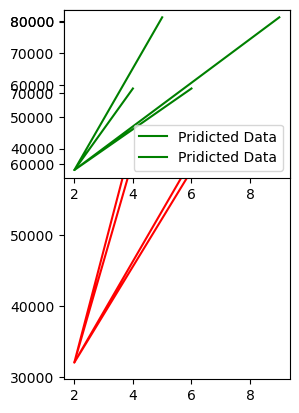

In [63]:
plt.subplot(1,2,1)
plt.plot(x_test,y_pred_line,color='red',label = 'Actual Data')
plt.subplot(2,2,1)

plt.plot(x_test,y_pred_poly,color='green',label = 'Pridicted Data')

plt.legend()

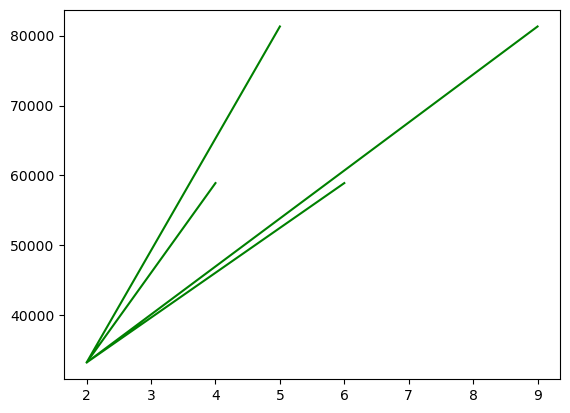